# PredicciÃ³n del consumo promedio de agua - experimento v11

Este notebook complementa los experimentos v7 a v10. EvalÃºa un modelo `XGBRegressor`
para estimar el consumo promedio de agua en 2024 usando entrenamiento temporal
2020-2023, excluyendo completamente la localidad de Sumapaz y retirando las
coordenadas geogrÃ¡ficas, la localidad y variables operativas con fuga de informaciÃ³n
de las variables predictoras. La localidad se conserva Ãºnicamente como metadato para
anÃ¡lisis por territorio y para construir baselines histÃ³ricos.

In [1]:
import hashlib
import itertools
import json
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import sklearn
import xgboost

from IPython.display import Markdown, display
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 300

RANDOM_STATE = 42
DATA_PATH = Path("df_consumo_bime_clima_v3.xlsx")
TARGET = "consumo_promedio"
YEAR_COL = "aÃ±o"
BIMESTER_COL = "BIMESTRE"
LOCALIDAD_COL = "localidad"

NOTEBOOK_HASHES_BASELINE = {'predic_consumo_agua.ipynb': '1ADF3CC3EEB35F15256C4EA58C3CF0FF4048BB97D655735B34F9FD39263E38EB', 'predic_consumo_agua_v2.ipynb': '18CBC8F73BB1ACE3DBC391FDA5F3E1BD373459F4F5AC48F662E034FE40DFDB60', 'predic_consumo_agua_v3.ipynb': '52F9F75781D6714CB8841E84958C639CD3DACC4DFB649092D8E94FBF16385F0D', 'predic_consumo_agua_v4.ipynb': 'EDA0A1F25A0F4934E66FDB85D85134CAD0C46119E07F20F4741C6D7E14E7A31E', 'predic_consumo_agua_v5.ipynb': 'C5BEAAFA7590CE114F8B5BC4913F1B69A0819CC78009212E4D77FDFAEB044890', 'predic_consumo_agua_v6.ipynb': '2E52F31545F6E2EBB27E7430FD20A0A4838862AF1353970E2AF4503D80054E7C', 'predic_consumo_agua_v7.ipynb': 'DD7AC9A4E35C57BFAB3162E22D4F127A56A121D450D557E6332C4D821548AC8E', 'predic_consumo_agua_v8.ipynb': 'A7394F0374DD3078A3A849C9E64652BDC33E4633403004047CC9F7ACC4AAE4DF', 'predic_consumo_agua_v9.ipynb': '056FF757377AB742509F25B226441B390895D7710DA5D405E6C3BC57A5BE3283', 'predic_consumo_agua_v10.ipynb': '0B8E89598B2ECD1C2DCD9B6AFEE323C6407198D437B399C412E2AB3A210EB179'}
NOTEBOOKS_HISTORICOS = list(NOTEBOOK_HASHES_BASELINE)

print("Version pandas:", pd.__version__)
print("Version numpy:", np.__version__)
print("Version scikit-learn:", sklearn.__version__)
print("Version XGBoost:", xgboost.__version__)
print("Version SHAP:", shap.__version__)

C:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Version pandas: 2.3.3
Version numpy: 2.2.6
Version scikit-learn: 1.7.2
Version XGBoost: 2.1.4
Version SHAP: 0.49.1


## 1. Funciones auxiliares y controles metodolÃ³gicos

Las mÃ©tricas se calculan exclusivamente en la escala original de `consumo_promedio`.
El modelo se entrena sobre `log1p(consumo_promedio)` y las predicciones se revierten
con `expm1` antes de evaluar MAE, RMSE y RÂ².

In [2]:
def file_sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest().upper()


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def regression_metrics(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred)),
        "n_registros": int(len(y_true)),
    }


def predict_original_scale(model, X_imputed):
    return np.expm1(model.predict(X_imputed))


def fit_xgb_with_imputer(X_train, y_train_original, params):
    imputer = SimpleImputer(strategy="median")
    X_train_imp = imputer.fit_transform(X_train)
    model = XGBRegressor(**params)
    model.fit(X_train_imp, np.log1p(y_train_original))
    return model, imputer


def describe_comparison(xgb_value, baseline_value, metric_name):
    pct = (xgb_value - baseline_value) / baseline_value * 100 if baseline_value != 0 else np.nan
    if np.isclose(xgb_value, baseline_value):
        return pct, f"XGBoost igualÃ³ el {metric_name} del mejor baseline."
    if xgb_value < baseline_value:
        return pct, f"XGBoost presentÃ³ un {metric_name} {abs(pct):.2f} % menor que el mejor baseline."
    return pct, f"XGBoost presentÃ³ un {metric_name} {pct:.2f} % mayor que el mejor baseline."


def assert_historical_notebooks_unchanged():
    current_hashes = {name: file_sha256(name) for name in NOTEBOOKS_HISTORICOS}
    assert current_hashes == NOTEBOOK_HASHES_BASELINE, "AlgÃºn notebook histÃ³rico v1-v10 cambiÃ³ durante la ejecuciÃ³n de v11."
    return current_hashes

## 2. Carga, depuraciÃ³n y construcciÃ³n de variables predictoras

Se mantiene la unidad de anÃ¡lisis localidad-aÃ±o-bimestre y se excluye Sumapaz antes
de cualquier particiÃ³n, selecciÃ³n de hiperparÃ¡metros o ajuste de transformaciones.

In [3]:
df_raw = pd.read_excel(DATA_PATH)
df_raw.columns = [str(c).strip() for c in df_raw.columns]
assert TARGET in df_raw.columns, f"No se encontrÃ³ la variable objetivo {TARGET}."
if YEAR_COL not in df_raw.columns and "ano" in df_raw.columns:
    YEAR_COL = "ano"
if YEAR_COL not in df_raw.columns:
    first_col = df_raw.columns[0]
    first_as_year = pd.to_numeric(df_raw[first_col], errors="coerce")
    if first_as_year.between(1900, 2100).mean() > 0.9:
        YEAR_COL = first_col
assert YEAR_COL in df_raw.columns, f"No se encontrÃ³ la columna {YEAR_COL}."
assert BIMESTER_COL in df_raw.columns, f"No se encontrÃ³ la columna {BIMESTER_COL}."
assert LOCALIDAD_COL in df_raw.columns, f"No se encontrÃ³ la columna {LOCALIDAD_COL}."

df = df_raw.copy()
df[LOCALIDAD_COL] = df[LOCALIDAD_COL].astype(str).str.strip()
df["_localidad_normalizada"] = df[LOCALIDAD_COL].str.upper()
n_original = len(df)
n_sumapaz = int(df["_localidad_normalizada"].eq("SUMAPAZ").sum())
df = df.loc[~df["_localidad_normalizada"].eq("SUMAPAZ")].copy()
df = df.drop(columns=["_localidad_normalizada"])
df = df.sort_values([YEAR_COL, BIMESTER_COL, LOCALIDAD_COL]).reset_index(drop=True)
df["id_registro_v11"] = np.arange(len(df))
df["indice_tiempo"] = (df[YEAR_COL] - 2020) * 6 + (df[BIMESTER_COL] - 1)

LEAKAGE_COLUMNS = [
    "metros_cubicos",
    "facturas",
    "suscriptores_facturados",
    "suscriptores_con_medidor",
]

REDUNDANT_OR_DERIVED_COLUMNS = [
    "T2MWET",
    "T2MDEW",
    "T2M_RANGE",
    "WS10M_MAX",
    "WS10M_MIN",
    "WS10M_RANGE",
    "WS2M_MAX",
    "WS2M_MIN",
    "WS2M_RANGE",
    "WD10M",
    "WD2M",
    "ALLSKY_SFC_PAR_TOT",
    "CLRSKY_SFC_PAR_TOT",
    "ALLSKY_SFC_SW_DIFF",
    "ALLSKY_SFC_SW_DNI",
    "ALLSKY_SFC_UVA",
    "ALLSKY_SFC_UVB",
    "ALLSKY_SFC_UV_INDEX",
    "CLRSKY_SFC_SW_DWN",
    "TOA_SW_DWN",
]

TERRITORIAL_OR_ID_COLUMNS = [
    LOCALIDAD_COL,
    "latitud",
    "longitud",
    "LATITUD",
    "LONGITUD",
    "latitude",
    "longitude",
    "id_registro_v11",
    "indice_tiempo",
]

df_model = df.copy()
df_model["BIMESTRE_sin"] = np.sin(2 * np.pi * df_model[BIMESTER_COL] / 6)
df_model["BIMESTRE_cos"] = np.cos(2 * np.pi * df_model[BIMESTER_COL] / 6)

excluded_reasons = {}
for col in [TARGET, BIMESTER_COL]:
    if col in df_model.columns:
        excluded_reasons[col] = "Variable objetivo o bimestre original reemplazado por codificaciÃ³n cÃ­clica."
for col in LEAKAGE_COLUMNS:
    if col in df_model.columns:
        excluded_reasons[col] = "Excluida por fuga de informaciÃ³n operativa respecto al target."
for col in REDUNDANT_OR_DERIVED_COLUMNS:
    if col in df_model.columns:
        excluded_reasons[col] = "Excluida por redundancia o derivaciÃ³n, siguiendo v7-v10."
for col in TERRITORIAL_OR_ID_COLUMNS:
    if col in df_model.columns:
        excluded_reasons[col] = "Excluida como identificador espacial, territorial o metadato."

non_numeric_columns = [
    c for c in df_model.columns
    if c not in excluded_reasons and not pd.api.types.is_numeric_dtype(df_model[c])
]
for col in non_numeric_columns:
    excluded_reasons[col] = "Excluida por no ser numÃ©rica y no aplicar codificaciÃ³n categÃ³rica."

feature_cols = [
    c for c in df_model.columns
    if c not in excluded_reasons and pd.api.types.is_numeric_dtype(df_model[c])
]
X_all = df_model[feature_cols].copy()
y_all = df_model[TARGET].astype(float).copy()
meta_all = df[[LOCALIDAD_COL, YEAR_COL, BIMESTER_COL, "indice_tiempo", "id_registro_v11"]].copy()

assert n_original == 596, f"Se esperaban 596 registros originales y se encontraron {n_original}."
assert n_sumapaz > 0, "No se encontraron registros de Sumapaz para excluir."
assert len(df) == n_original - n_sumapaz
assert not meta_all[LOCALIDAD_COL].str.upper().eq("SUMAPAZ").any()
assert (y_all >= 0).all(), "log1p requiere que el target no tenga valores negativos."

forbidden_predictors = set(LEAKAGE_COLUMNS + TERRITORIAL_OR_ID_COLUMNS + [TARGET, BIMESTER_COL])
forbidden_predictors.update({"_row_id", "row_id", "codigo_localidad", "cod_localidad"})
assert not forbidden_predictors.intersection(feature_cols), forbidden_predictors.intersection(feature_cols)

variables_utilizadas = []
for col in df_model.columns:
    if col in feature_cols:
        variables_utilizadas.append({
            "variable": col,
            "estado": "incluida",
            "razon": "Variable predictora numÃ©rica usada por XGBoost.",
            "tipo": str(df_model[col].dtype),
        })
    elif col in excluded_reasons:
        variables_utilizadas.append({
            "variable": col,
            "estado": "excluida",
            "razon": excluded_reasons[col],
            "tipo": str(df_model[col].dtype),
        })
variables_utilizadas = pd.DataFrame(variables_utilizadas).sort_values(["estado", "variable"])
variables_utilizadas.to_csv("variables_utilizadas_v11.csv", index=False, encoding="utf-8-sig")

print(f"Registros originales: {n_original}")
print(f"Columna de aÃ±o utilizada: {YEAR_COL}")
print(f"Registros de Sumapaz excluidos: {n_sumapaz}")
print(f"Registros despuÃ©s de excluir Sumapaz: {len(df)}")
print(f"Variables predictoras utilizadas ({len(feature_cols)}):")
display(pd.DataFrame({"variable": feature_cols}))
display(variables_utilizadas)

Registros originales: 596
Columna de aÃ±o utilizada: año
Registros de Sumapaz excluidos: 26
Registros despuÃ©s de excluir Sumapaz: 570
Variables predictoras utilizadas (22):


,variable
0,año
1,ALLSKY_SFC_LW_DWN
2,ALLSKY_SFC_SW_DWN
3,ALLSKY_SRF_ALB
4,CLOUD_AMT
5,GWETPROF
6,GWETROOT
7,GWETTOP
8,ONI
9,PRECTOTCORR


,variable,estado,razon,tipo
11,ALLSKY_SFC_PAR_TOT,excluida,"Excluida por redundancia o derivaciÃ³n, siguie...",float64
12,ALLSKY_SFC_SW_DIFF,excluida,"Excluida por redundancia o derivaciÃ³n, siguie...",float64
13,ALLSKY_SFC_SW_DNI,excluida,"Excluida por redundancia o derivaciÃ³n, siguie...",float64
15,ALLSKY_SFC_UVA,excluida,"Excluida por redundancia o derivaciÃ³n, siguie...",float64
16,ALLSKY_SFC_UVB,excluida,"Excluida por redundancia o derivaciÃ³n, siguie...",float64
17,ALLSKY_SFC_UV_INDEX,excluida,"Excluida por redundancia o derivaciÃ³n, siguie...",float64
2,BIMESTRE,excluida,Variable objetivo o bimestre original reemplaz...,int64
20,CLRSKY_SFC_PAR_TOT,excluida,"Excluida por redundancia o derivaciÃ³n, siguie...",float64
21,CLRSKY_SFC_SW_DWN,excluida,"Excluida por redundancia o derivaciÃ³n, siguie...",float64
32,T2MDEW,excluida,"Excluida por redundancia o derivaciÃ³n, siguie...",float64


## 3. DivisiÃ³n temporal e hiperparÃ¡metros con validaciÃ³n interna 2020-2023

La bÃºsqueda se realiza con ventana expansiva dentro de 2020-2023. El aÃ±o 2024 no
participa en selecciÃ³n de variables, imputaciÃ³n, transformaciÃ³n ni selecciÃ³n de
hiperparÃ¡metros.

In [4]:
train_final_mask = meta_all[YEAR_COL].between(2020, 2023)
test_2024_mask = meta_all[YEAR_COL].eq(2024)

assert set(meta_all.loc[train_final_mask, YEAR_COL].unique()).issubset({2020, 2021, 2022, 2023})
assert set(meta_all.loc[test_2024_mask, YEAR_COL].unique()) == {2024}
assert train_final_mask.sum() + test_2024_mask.sum() == len(df)

internal_folds = [
    ([2020], 2021),
    ([2020, 2021], 2022),
    ([2020, 2021, 2022], 2023),
]

param_grid = []
for values in itertools.product(
    [100, 200],
    [0.03, 0.05],
    [3, 4],
    [1, 3],
    [0.8, 1.0],
    [0.8],
    [0.0],
    [1.0, 5.0],
):
    n_estimators, learning_rate, max_depth, min_child_weight, subsample, colsample_bytree, reg_alpha, reg_lambda = values
    param_grid.append({
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "tree_method": "hist",
        "n_estimators": n_estimators,
        "learning_rate": learning_rate,
        "max_depth": max_depth,
        "min_child_weight": min_child_weight,
        "subsample": subsample,
        "colsample_bytree": colsample_bytree,
        "reg_alpha": reg_alpha,
        "reg_lambda": reg_lambda,
    })

validation_rows = []
for config_id, params in enumerate(param_grid, start=1):
    for train_years, val_year in internal_folds:
        fold_train_mask = meta_all[YEAR_COL].isin(train_years)
        fold_val_mask = meta_all[YEAR_COL].eq(val_year)
        assert set(meta_all.loc[fold_train_mask, YEAR_COL].unique()).issubset({2020, 2021, 2022})
        assert val_year in {2021, 2022, 2023}
        assert not meta_all.loc[fold_train_mask | fold_val_mask, YEAR_COL].eq(2024).any()

        model, imputer = fit_xgb_with_imputer(
            X_all.loc[fold_train_mask, feature_cols],
            y_all.loc[fold_train_mask],
            params,
        )
        X_val_imp = imputer.transform(X_all.loc[fold_val_mask, feature_cols])
        y_val = y_all.loc[fold_val_mask].to_numpy()
        pred_val = predict_original_scale(model, X_val_imp)
        metrics = regression_metrics(y_val, pred_val)

        row = {
            "config_id": config_id,
            "train_years": ",".join(map(str, train_years)),
            "validation_year": val_year,
            "n_train": int(fold_train_mask.sum()),
            "n_validation": int(fold_val_mask.sum()),
            "metrics_scale": "original_expm1",
            **{k: v for k, v in params.items() if k not in {"n_jobs", "tree_method"}},
            **metrics,
        }
        validation_rows.append(row)

resultados_validacion_temporal_interna = pd.DataFrame(validation_rows)
resultados_validacion_temporal_interna.to_csv(
    "resultados_v11_validacion_temporal_interna.csv", index=False, encoding="utf-8-sig"
)

hyperparam_cols = [
    "n_estimators", "learning_rate", "max_depth", "min_child_weight",
    "subsample", "colsample_bytree", "reg_alpha", "reg_lambda",
    "objective", "eval_metric", "random_state",
]
hiperparametros_v11 = (
    resultados_validacion_temporal_interna
    .groupby(["config_id"] + hyperparam_cols, as_index=False)
    .agg(
        RMSE_promedio=("RMSE", "mean"),
        MAE_promedio=("MAE", "mean"),
        R2_promedio=("R2", "mean"),
        RMSE_desv=("RMSE", "std"),
        MAE_desv=("MAE", "std"),
    )
    .sort_values(["RMSE_promedio", "MAE_promedio", "R2_promedio"], ascending=[True, True, False])
    .reset_index(drop=True)
)
hiperparametros_v11["seleccionado"] = False
hiperparametros_v11.loc[0, "seleccionado"] = True
hiperparametros_v11.to_csv("hiperparametros_v11.csv", index=False, encoding="utf-8-sig")

best_config = hiperparametros_v11.loc[0].to_dict()
best_params = {
    "objective": best_config["objective"],
    "eval_metric": best_config["eval_metric"],
    "random_state": int(best_config["random_state"]),
    "n_jobs": -1,
    "tree_method": "hist",
    "n_estimators": int(best_config["n_estimators"]),
    "learning_rate": float(best_config["learning_rate"]),
    "max_depth": int(best_config["max_depth"]),
    "min_child_weight": int(best_config["min_child_weight"]),
    "subsample": float(best_config["subsample"]),
    "colsample_bytree": float(best_config["colsample_bytree"]),
    "reg_alpha": float(best_config["reg_alpha"]),
    "reg_lambda": float(best_config["reg_lambda"]),
}

print("Mejor configuraciÃ³n seleccionada por RMSE promedio interno:")
display(hiperparametros_v11.head(10))
print(json.dumps({k: v for k, v in best_params.items() if k not in {"n_jobs", "tree_method"}}, indent=2))

Mejor configuraciÃ³n seleccionada por RMSE promedio interno:


,config_id,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_alpha,reg_lambda,objective,eval_metric,random_state,RMSE_promedio,MAE_promedio,R2_promedio,RMSE_desv,MAE_desv,seleccionado
0,28,100,0.05,4,1,1.0,0.8,0.0,5.0,reg:squarederror,rmse,42,2.084261,1.419981,-0.000780,0.267521,0.149586,True
1,12,100,0.03,4,1,1.0,0.8,0.0,5.0,reg:squarederror,rmse,42,2.085247,1.415827,-0.002046,0.262070,0.141064,False
2,60,200,0.05,4,1,1.0,0.8,0.0,5.0,reg:squarederror,rmse,42,2.086249,1.419527,-0.002673,0.268348,0.158630,False
3,44,200,0.03,4,1,1.0,0.8,0.0,5.0,reg:squarederror,rmse,42,2.087437,1.420718,-0.003794,0.269788,0.154295,False
4,20,100,0.05,3,1,1.0,0.8,0.0,5.0,reg:squarederror,rmse,42,2.093931,1.396020,-0.009775,0.290640,0.114868,False
5,4,100,0.03,3,1,1.0,0.8,0.0,5.0,reg:squarederror,rmse,42,2.095395,1.393187,-0.011470,0.285209,0.107791,False
6,32,100,0.05,4,3,1.0,0.8,0.0,5.0,reg:squarederror,rmse,42,2.097440,1.433510,-0.012968,0.287791,0.158418,False
7,52,200,0.05,3,1,1.0,0.8,0.0,5.0,reg:squarederror,rmse,42,2.097611,1.394358,-0.013243,0.296172,0.123814,False
8,64,200,0.05,4,3,1.0,0.8,0.0,5.0,reg:squarederror,rmse,42,2.097965,1.432425,-0.013340,0.290558,0.170702,False
9,16,100,0.03,4,3,1.0,0.8,0.0,5.0,reg:squarederror,rmse,42,2.098109,1.431432,-0.013964,0.281217,0.144025,False


{
  "objective": "reg:squarederror",
  "eval_metric": "rmse",
  "random_state": 42,
  "n_estimators": 100,
  "learning_rate": 0.05,
  "max_depth": 4,
  "min_child_weight": 1,
  "subsample": 1.0,
  "colsample_bytree": 0.8,
  "reg_alpha": 0.0,
  "reg_lambda": 5.0
}


## 4. Entrenamiento final 2020-2023 y evaluaciÃ³n Ãºnica sobre 2024

DespuÃ©s de seleccionar los hiperparÃ¡metros, se reajusta la imputaciÃ³n Ãºnicamente
con 2020-2023 y se entrena el modelo definitivo con todos los registros disponibles
de ese periodo. La prueba final se realiza una sola vez sobre 2024.

In [5]:
X_train_final = X_all.loc[train_final_mask, feature_cols].copy()
y_train_final = y_all.loc[train_final_mask].copy()
X_test_2024 = X_all.loc[test_2024_mask, feature_cols].copy()
y_test_2024 = y_all.loc[test_2024_mask].copy()
meta_train_final = meta_all.loc[train_final_mask].copy().reset_index(drop=True)
meta_test_2024 = meta_all.loc[test_2024_mask].copy().reset_index(drop=True)

final_model, final_imputer = fit_xgb_with_imputer(X_train_final, y_train_final, best_params)
X_test_2024_imp = final_imputer.transform(X_test_2024)
X_train_final_imp = final_imputer.transform(X_train_final)
pred_xgb_2024 = predict_original_scale(final_model, X_test_2024_imp)
pred_xgb_train = predict_original_scale(final_model, X_train_final_imp)

assert set(meta_train_final[YEAR_COL].unique()).issubset({2020, 2021, 2022, 2023})
assert set(meta_test_2024[YEAR_COL].unique()) == {2024}
assert not meta_train_final[LOCALIDAD_COL].str.upper().eq("SUMAPAZ").any()
assert not meta_test_2024[LOCALIDAD_COL].str.upper().eq("SUMAPAZ").any()
assert final_imputer.statistics_.shape[0] == len(feature_cols)

metrics_xgb_2024 = regression_metrics(y_test_2024.to_numpy(), pred_xgb_2024)
metrics_xgb_train = regression_metrics(y_train_final.to_numpy(), pred_xgb_train)

resultados_prueba_2024 = pd.DataFrame([{
    "modelo": "XGBoost",
    "descripcion": "XGBRegressor sin coordenadas, sin localidad y sin Sumapaz",
    "conjunto": "prueba_2024",
    "anos_entrenamiento": "2020-2023",
    "ano_prueba": 2024,
    "n_features": len(feature_cols),
    "metrics_scale": "original_expm1",
    **metrics_xgb_2024,
}])
resultados_prueba_2024.to_csv("resultados_v11_prueba_2024.csv", index=False, encoding="utf-8-sig")

print("MÃ©tricas XGBoost en entrenamiento 2020-2023:")
display(pd.DataFrame([{**metrics_xgb_train, "conjunto": "entrenamiento_2020_2023"}]))
print("MÃ©tricas XGBoost en prueba 2024:")
display(resultados_prueba_2024)

MÃ©tricas XGBoost en entrenamiento 2020-2023:


,MAE,RMSE,R2,n_registros,conjunto
0,1.359426,2.005414,0.103003,456,entrenamiento_2020_2023


MÃ©tricas XGBoost en prueba 2024:


,modelo,descripcion,conjunto,anos_entrenamiento,ano_prueba,n_features,metrics_scale,MAE,RMSE,R2,n_registros
0,XGBoost,"XGBRegressor sin coordenadas, sin localidad y ...",prueba_2024,2020-2023,2024,22,original_expm1,1.582917,1.932494,-0.064793,114


## 5. Baselines histÃ³ricos con informaciÃ³n 2020-2023

Los baselines utilizan exclusivamente informaciÃ³n histÃ³rica previa a 2024. La
localidad se usa como clave de agrupaciÃ³n para estos modelos de referencia, no como
predictor del modelo XGBoost.

In [6]:
train_hist = df.loc[train_final_mask].copy()
test_hist = df.loc[test_2024_mask].copy().reset_index(drop=True)

global_mean = float(train_hist[TARGET].mean())
loc_mean = train_hist.groupby(LOCALIDAD_COL)[TARGET].mean().to_dict()
loc_bim_mean = train_hist.groupby([LOCALIDAD_COL, BIMESTER_COL])[TARGET].mean().to_dict()
seasonal_2023 = (
    train_hist.loc[train_hist[YEAR_COL].eq(2023)]
    .set_index([LOCALIDAD_COL, BIMESTER_COL])[TARGET]
    .to_dict()
)

def baseline_predictions(test_df, baseline_name):
    preds = []
    fallbacks = []
    for _, row in test_df.iterrows():
        key_loc = row[LOCALIDAD_COL]
        key_bim = row[BIMESTER_COL]
        if baseline_name == "media_global":
            preds.append(global_mean)
            fallbacks.append("media_global")
        elif baseline_name == "media_localidad":
            if key_loc in loc_mean:
                preds.append(float(loc_mean[key_loc]))
                fallbacks.append("media_localidad")
            else:
                preds.append(global_mean)
                fallbacks.append("fallback_media_global")
        elif baseline_name == "media_localidad_bimestre":
            if (key_loc, key_bim) in loc_bim_mean:
                preds.append(float(loc_bim_mean[(key_loc, key_bim)]))
                fallbacks.append("media_localidad_bimestre")
            elif key_loc in loc_mean:
                preds.append(float(loc_mean[key_loc]))
                fallbacks.append("fallback_media_localidad")
            else:
                preds.append(global_mean)
                fallbacks.append("fallback_media_global")
        elif baseline_name == "seasonal_naive":
            if (key_loc, key_bim) in seasonal_2023:
                preds.append(float(seasonal_2023[(key_loc, key_bim)]))
                fallbacks.append("mismo_bimestre_2023")
            elif (key_loc, key_bim) in loc_bim_mean:
                preds.append(float(loc_bim_mean[(key_loc, key_bim)]))
                fallbacks.append("fallback_media_localidad_bimestre")
            elif key_loc in loc_mean:
                preds.append(float(loc_mean[key_loc]))
                fallbacks.append("fallback_media_localidad")
            else:
                preds.append(global_mean)
                fallbacks.append("fallback_media_global")
        else:
            raise ValueError(f"Baseline no reconocido: {baseline_name}")
    return np.asarray(preds, dtype=float), fallbacks

baseline_names = [
    "media_global",
    "media_localidad",
    "media_localidad_bimestre",
    "seasonal_naive",
]
baseline_labels = {
    "media_global": "Baseline - media histÃ³rica global",
    "media_localidad": "Baseline - media histÃ³rica por localidad",
    "media_localidad_bimestre": "Baseline - media histÃ³rica localidad-bimestre",
    "seasonal_naive": "Baseline - estacional ingenuo 2023",
}

baseline_results = []
prediction_rows = []

xgb_pred_df = meta_test_2024.copy()
xgb_pred_df["valor_real"] = y_test_2024.to_numpy()
xgb_pred_df["prediccion"] = pred_xgb_2024
xgb_pred_df["modelo"] = "XGBoost"
xgb_pred_df["tipo"] = "modelo"
xgb_pred_df["regla_utilizada"] = "modelo_entrenado_2020_2023"
xgb_pred_df["error"] = xgb_pred_df["valor_real"] - xgb_pred_df["prediccion"]
xgb_pred_df["error_absoluto"] = xgb_pred_df["error"].abs()
prediction_rows.append(xgb_pred_df)

for baseline_name in baseline_names:
    preds, fallbacks = baseline_predictions(test_hist, baseline_name)
    metrics = regression_metrics(test_hist[TARGET].to_numpy(), preds)
    baseline_results.append({
        "baseline": baseline_name,
        "modelo_o_baseline": baseline_labels[baseline_name],
        "conjunto": "prueba_2024",
        "anos_entrenamiento": "2020-2023",
        "ano_prueba": 2024,
        "metrics_scale": "original",
        **metrics,
    })
    pred_df = meta_test_2024.copy()
    pred_df["valor_real"] = test_hist[TARGET].to_numpy()
    pred_df["prediccion"] = preds
    pred_df["modelo"] = baseline_labels[baseline_name]
    pred_df["tipo"] = "baseline"
    pred_df["regla_utilizada"] = fallbacks
    pred_df["error"] = pred_df["valor_real"] - pred_df["prediccion"]
    pred_df["error_absoluto"] = pred_df["error"].abs()
    prediction_rows.append(pred_df)

resultados_baselines_2024 = pd.DataFrame(baseline_results).sort_values(["RMSE", "MAE"]).reset_index(drop=True)
resultados_baselines_2024.to_csv("resultados_v11_baselines_2024.csv", index=False, encoding="utf-8-sig")

predicciones_v11_2024 = pd.concat(prediction_rows, ignore_index=True)
predicciones_v11_2024 = predicciones_v11_2024[
    ["modelo", "tipo", LOCALIDAD_COL, YEAR_COL, BIMESTER_COL, "id_registro_v11", "valor_real", "prediccion", "error", "error_absoluto", "regla_utilizada"]
]
predicciones_v11_2024.to_csv("predicciones_v11_2024.csv", index=False, encoding="utf-8-sig")

best_baseline_row = resultados_baselines_2024.iloc[0].copy()
xgb_row = resultados_prueba_2024.iloc[0].copy()
pct_mae, text_mae = describe_comparison(xgb_row["MAE"], best_baseline_row["MAE"], "MAE")
pct_rmse, text_rmse = describe_comparison(xgb_row["RMSE"], best_baseline_row["RMSE"], "RMSE")

comparacion_rows = []
comparacion_rows.append({
    "modelo": "XGBoost",
    "tipo": "modelo",
    "baseline": "",
    "n_registros": xgb_row["n_registros"],
    "MAE": xgb_row["MAE"],
    "RMSE": xgb_row["RMSE"],
    "R2": xgb_row["R2"],
    "diferencia_MAE_vs_mejor_baseline": xgb_row["MAE"] - best_baseline_row["MAE"],
    "diferencia_RMSE_vs_mejor_baseline": xgb_row["RMSE"] - best_baseline_row["RMSE"],
    "diferencia_pct_MAE_vs_mejor_baseline": pct_mae,
    "diferencia_pct_RMSE_vs_mejor_baseline": pct_rmse,
    "resultado_vs_mejor_baseline": "supera" if xgb_row["RMSE"] < best_baseline_row["RMSE"] else ("iguala" if np.isclose(xgb_row["RMSE"], best_baseline_row["RMSE"]) else "es superado"),
    "mejor_baseline_referencia": best_baseline_row["modelo_o_baseline"],
})
for _, row in resultados_baselines_2024.iterrows():
    comparacion_rows.append({
        "modelo": row["modelo_o_baseline"],
        "tipo": "baseline",
        "baseline": row["baseline"],
        "n_registros": row["n_registros"],
        "MAE": row["MAE"],
        "RMSE": row["RMSE"],
        "R2": row["R2"],
        "diferencia_MAE_vs_mejor_baseline": row["MAE"] - best_baseline_row["MAE"],
        "diferencia_RMSE_vs_mejor_baseline": row["RMSE"] - best_baseline_row["RMSE"],
        "diferencia_pct_MAE_vs_mejor_baseline": (row["MAE"] - best_baseline_row["MAE"]) / best_baseline_row["MAE"] * 100,
        "diferencia_pct_RMSE_vs_mejor_baseline": (row["RMSE"] - best_baseline_row["RMSE"]) / best_baseline_row["RMSE"] * 100,
        "resultado_vs_mejor_baseline": "referencia" if row["baseline"] == best_baseline_row["baseline"] else "comparativo",
        "mejor_baseline_referencia": best_baseline_row["modelo_o_baseline"],
    })

comparacion_v11_modelos_2024 = (
    pd.DataFrame(comparacion_rows)
    .sort_values(["RMSE", "MAE"], ascending=[True, True])
    .reset_index(drop=True)
)
comparacion_v11_modelos_2024["ranking"] = np.arange(1, len(comparacion_v11_modelos_2024) + 1)
comparacion_v11_modelos_2024.to_csv("comparacion_v11_modelos_2024.csv", index=False, encoding="utf-8-sig")

print("Resultados de baselines en 2024:")
display(resultados_baselines_2024)
print("ComparaciÃ³n final en 2024:")
display(comparacion_v11_modelos_2024)
print(text_mae)
print(text_rmse)

Resultados de baselines en 2024:


,baseline,modelo_o_baseline,conjunto,anos_entrenamiento,ano_prueba,metrics_scale,MAE,RMSE,R2,n_registros
0,media_localidad_bimestre,Baseline - media histÃ³rica localidad-bimestre,prueba_2024,2020-2023,2024,original,0.687651,0.961845,0.736222,114
1,media_localidad,Baseline - media histÃ³rica por localidad,prueba_2024,2020-2023,2024,original,0.735456,1.063742,0.677372,114
2,seasonal_naive,Baseline - estacional ingenuo 2023,prueba_2024,2020-2023,2024,original,0.823337,1.215437,0.578795,114
3,media_global,Baseline - media histÃ³rica global,prueba_2024,2020-2023,2024,original,1.615505,1.970189,-0.106738,114


ComparaciÃ³n final en 2024:


,modelo,tipo,baseline,n_registros,MAE,RMSE,R2,diferencia_MAE_vs_mejor_baseline,diferencia_RMSE_vs_mejor_baseline,diferencia_pct_MAE_vs_mejor_baseline,diferencia_pct_RMSE_vs_mejor_baseline,resultado_vs_mejor_baseline,mejor_baseline_referencia,ranking
0,Baseline - media histÃ³rica localidad-bimestre,baseline,media_localidad_bimestre,114,0.687651,0.961845,0.736222,0.000000,0.000000,0.000000,0.000000,referencia,Baseline - media histÃ³rica localidad-bimestre,1
1,Baseline - media histÃ³rica por localidad,baseline,media_localidad,114,0.735456,1.063742,0.677372,0.047804,0.101897,6.951818,10.593958,comparativo,Baseline - media histÃ³rica localidad-bimestre,2
2,Baseline - estacional ingenuo 2023,baseline,seasonal_naive,114,0.823337,1.215437,0.578795,0.135686,0.253592,19.731762,26.365174,comparativo,Baseline - media histÃ³rica localidad-bimestre,3
3,XGBoost,modelo,,114,1.582917,1.932494,-0.064793,0.895266,0.970649,130.191800,100.915295,es superado,Baseline - media histÃ³rica localidad-bimestre,4
4,Baseline - media histÃ³rica global,baseline,media_global,114,1.615505,1.970189,-0.106738,0.927854,1.008345,134.930829,104.834413,comparativo,Baseline - media histÃ³rica localidad-bimestre,5


XGBoost presentÃ³ un MAE 130.19 % mayor que el mejor baseline.
XGBoost presentÃ³ un RMSE 100.92 % mayor que el mejor baseline.


## 6. Resultados por localidad

La comparaciÃ³n territorial utiliza el mejor baseline global seleccionado por RMSE
sobre 2024 y clasifica la diferencia con un umbral de similitud del 5 %.

In [7]:
best_baseline_model_name = best_baseline_row["modelo_o_baseline"]
xgb_local = predicciones_v11_2024.loc[predicciones_v11_2024["modelo"].eq("XGBoost")].copy()
baseline_local = predicciones_v11_2024.loc[predicciones_v11_2024["modelo"].eq(best_baseline_model_name)].copy()

local_rows = []
for localidad, gx in xgb_local.groupby(LOCALIDAD_COL):
    gb = baseline_local.loc[baseline_local[LOCALIDAD_COL].eq(localidad)]
    assert set(gx["id_registro_v11"]) == set(gb["id_registro_v11"])
    mx = regression_metrics(gx["valor_real"], gx["prediccion"])
    mb = regression_metrics(gb["valor_real"], gb["prediccion"])
    pct_diff_rmse = (mx["RMSE"] - mb["RMSE"]) / mb["RMSE"] * 100 if mb["RMSE"] != 0 else np.nan
    if pct_diff_rmse <= -5:
        best_model = "XGBoost supera al baseline"
    elif pct_diff_rmse >= 5:
        best_model = "El baseline supera a XGBoost"
    else:
        best_model = "Resultados similares"
    local_rows.append({
        LOCALIDAD_COL: localidad,
        "n_test": int(len(gx)),
        "MAE_XGBoost": mx["MAE"],
        "RMSE_XGBoost": mx["RMSE"],
        "MAE_mejor_baseline": mb["MAE"],
        "RMSE_mejor_baseline": mb["RMSE"],
        "diferencia_pct_RMSE_XGBoost_vs_baseline": pct_diff_rmse,
        "modelo_con_mejor_resultado": best_model,
        "mejor_baseline_referencia": best_baseline_model_name,
    })

resultados_v11_por_localidad = pd.DataFrame(local_rows).sort_values(LOCALIDAD_COL).reset_index(drop=True)
resultados_v11_por_localidad.to_csv("resultados_v11_por_localidad.csv", index=False, encoding="utf-8-sig")

conteo_localidades = resultados_v11_por_localidad["modelo_con_mejor_resultado"].value_counts().rename_axis("categoria").reset_index(name="n_localidades")
display(resultados_v11_por_localidad)
display(conteo_localidades)

,localidad,n_test,MAE_XGBoost,RMSE_XGBoost,MAE_mejor_baseline,RMSE_mejor_baseline,diferencia_pct_RMSE_XGBoost_vs_baseline,modelo_con_mejor_resultado,mejor_baseline_referencia
0,ANTONIO NARINO,6,1.680498,1.874130,0.808284,1.024635,82.906982,El baseline supera a XGBoost,Baseline - media histÃ³rica localidad-bimestre
1,BARRIOS UNIDOS,6,1.249841,1.349237,0.688515,0.811124,66.341665,El baseline supera a XGBoost,Baseline - media histÃ³rica localidad-bimestre
2,BOSA,6,2.529316,2.556834,0.375929,0.508119,403.195711,El baseline supera a XGBoost,Baseline - media histÃ³rica localidad-bimestre
3,CHAPINERO,6,0.400774,0.418477,0.292138,0.354131,18.169984,El baseline supera a XGBoost,Baseline - media histÃ³rica localidad-bimestre
4,CIUDAD BOLIVAR,6,1.440627,1.590871,0.637261,0.897637,77.228803,El baseline supera a XGBoost,Baseline - media histÃ³rica localidad-bimestre
5,ENGATIVA,6,2.004096,2.073636,0.497032,0.652884,217.611909,El baseline supera a XGBoost,Baseline - media histÃ³rica localidad-bimestre
6,FONTIBON,6,0.523083,0.678111,0.640754,0.668037,1.508002,Resultados similares,Baseline - media histÃ³rica localidad-bimestre
7,KENNEDY,6,1.815243,1.859935,0.352838,0.488297,280.902427,El baseline supera a XGBoost,Baseline - media histÃ³rica localidad-bimestre
8,LA CANDELARIA,6,4.092823,4.578427,1.351393,1.890083,142.234184,El baseline supera a XGBoost,Baseline - media histÃ³rica localidad-bimestre
9,LOS MARTIRES,6,1.206320,1.466349,0.945164,1.149107,27.607716,El baseline supera a XGBoost,Baseline - media histÃ³rica localidad-bimestre


,categoria,n_localidades
0,El baseline supera a XGBoost,17
1,Resultados similares,2


## 7. Interpretabilidad: importancia por permutaciÃ³n y SHAP

La interpretaciÃ³n se limita a contribuciÃ³n predictiva. No se realizan inferencias
causales a partir de la importancia de variables.

In [8]:
X_test_2024_imp_df = pd.DataFrame(X_test_2024_imp, columns=feature_cols, index=X_test_2024.index)

def neg_mae_original(estimator, X, y_original):
    pred = np.expm1(estimator.predict(X))
    return -mean_absolute_error(y_original, pred)

perm_mae = permutation_importance(
    final_model,
    X_test_2024_imp_df,
    y_test_2024.to_numpy(),
    scoring=neg_mae_original,
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
importancia_permutacion_v11 = pd.DataFrame({
    "variable": feature_cols,
    "aumento_MAE_promedio": perm_mae.importances_mean,
    "aumento_MAE_desv": perm_mae.importances_std,
}).sort_values("aumento_MAE_promedio", ascending=False).reset_index(drop=True)
importancia_permutacion_v11["ranking"] = np.arange(1, len(importancia_permutacion_v11) + 1)
importancia_permutacion_v11.to_csv("importancia_permutacion_v11.csv", index=False, encoding="utf-8-sig")

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_2024_imp_df)
if isinstance(shap_values, list):
    shap_values = shap_values[0]
importancia_shap_v11 = pd.DataFrame({
    "variable": feature_cols,
    "media_abs_SHAP_log_target": np.abs(shap_values).mean(axis=0),
}).sort_values("media_abs_SHAP_log_target", ascending=False).reset_index(drop=True)
importancia_shap_v11["ranking"] = np.arange(1, len(importancia_shap_v11) + 1)
importancia_shap_v11.to_csv("importancia_shap_v11.csv", index=False, encoding="utf-8-sig")

print("Top 10 importancia por permutaciÃ³n:")
display(importancia_permutacion_v11.head(10))
print("Top 10 importancia SHAP:")
display(importancia_shap_v11.head(10))

Top 10 importancia por permutaciÃ³n:


,variable,aumento_MAE_promedio,aumento_MAE_desv,ranking
0,PS,0.060007,0.030420,1
1,QV2M,0.011207,0.004174,2
2,T2M,0.003278,0.011363,3
3,ALLSKY_SRF_ALB,0.002122,0.001137,4
4,BIMESTRE_sin,0.002051,0.002518,5
5,ONI,0.002030,0.004375,6
6,PRECTOTCORR_SUM,0.000752,0.001137,7
7,TS,0.000747,0.001287,8
8,ALLSKY_SFC_LW_DWN,0.000746,0.000588,9
9,GWETTOP,0.000583,0.000485,10


Top 10 importancia SHAP:


,variable,media_abs_SHAP_log_target,ranking
0,PS,0.022136,1
1,T2M,0.008158,2
2,PRECTOTCORR,0.005550,3
3,ALLSKY_SRF_ALB,0.005494,4
4,CLOUD_AMT,0.004774,5
5,QV2M,0.004663,6
6,ALLSKY_SFC_LW_DWN,0.003293,7
7,BIMESTRE_sin,0.002657,8
8,ONI,0.002045,9
9,año,0.001620,10


## 8. Visualizaciones de evaluaciÃ³n

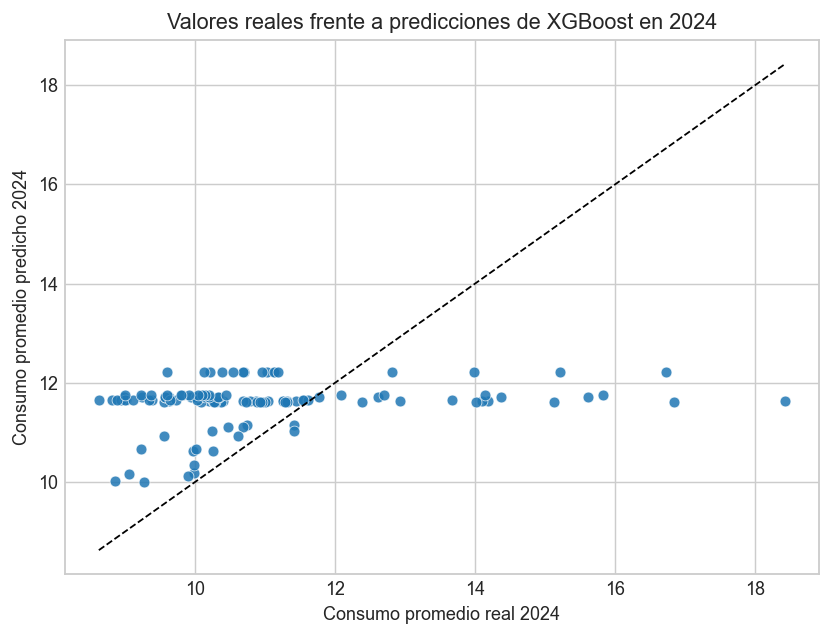

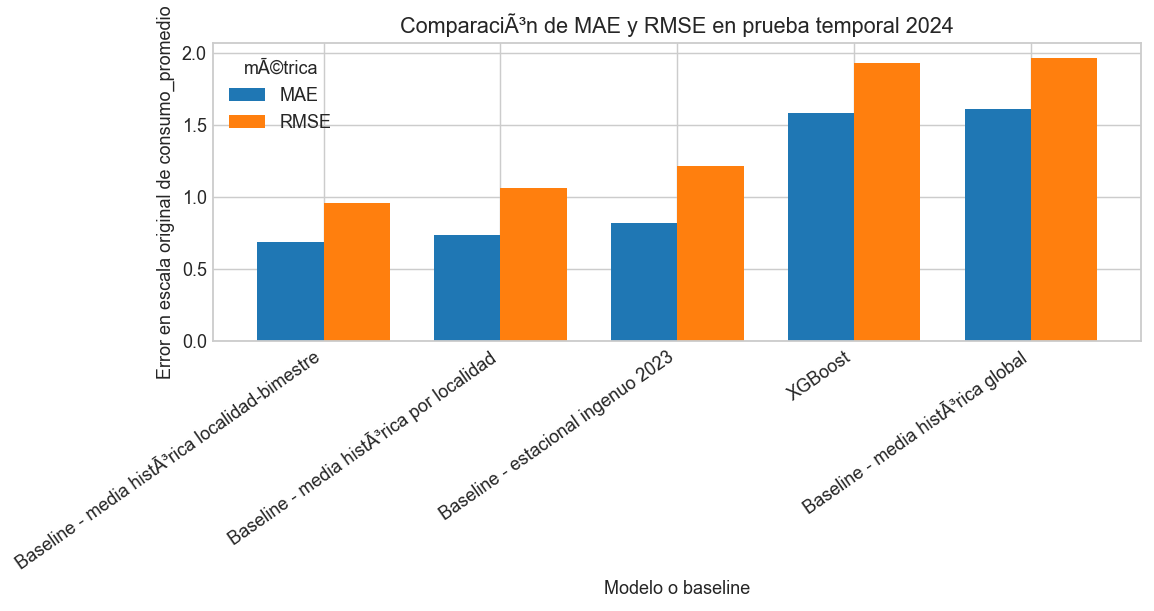

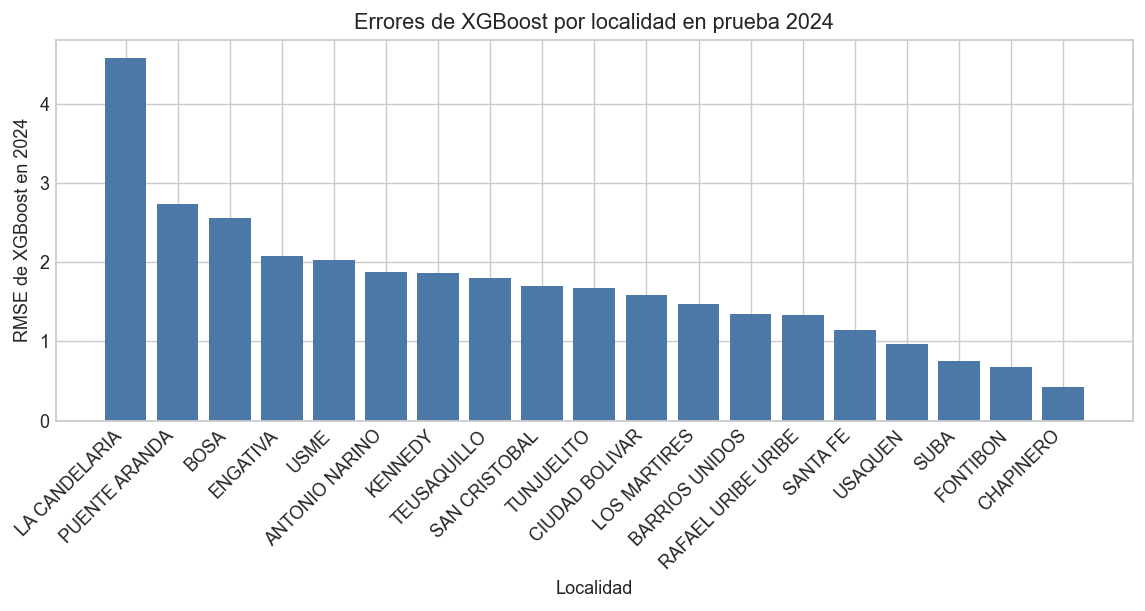

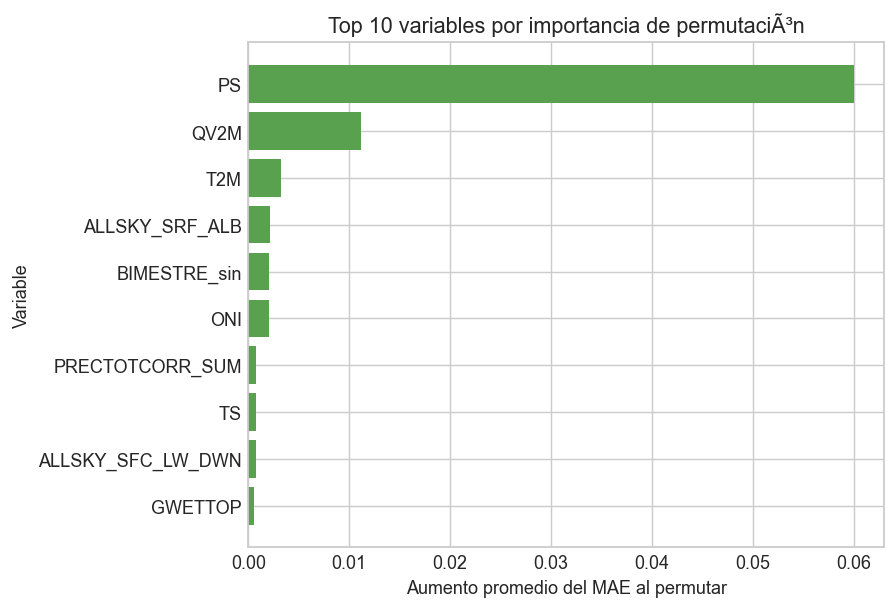

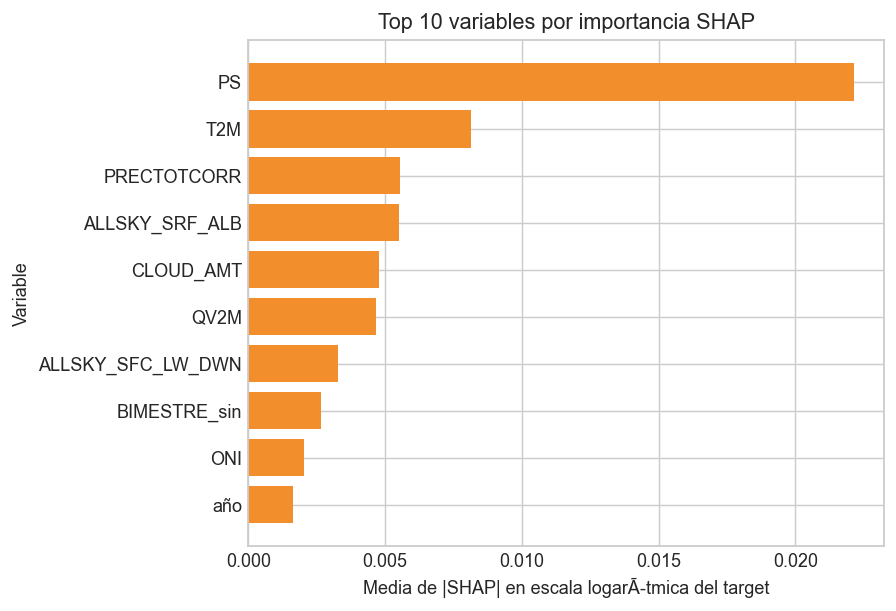

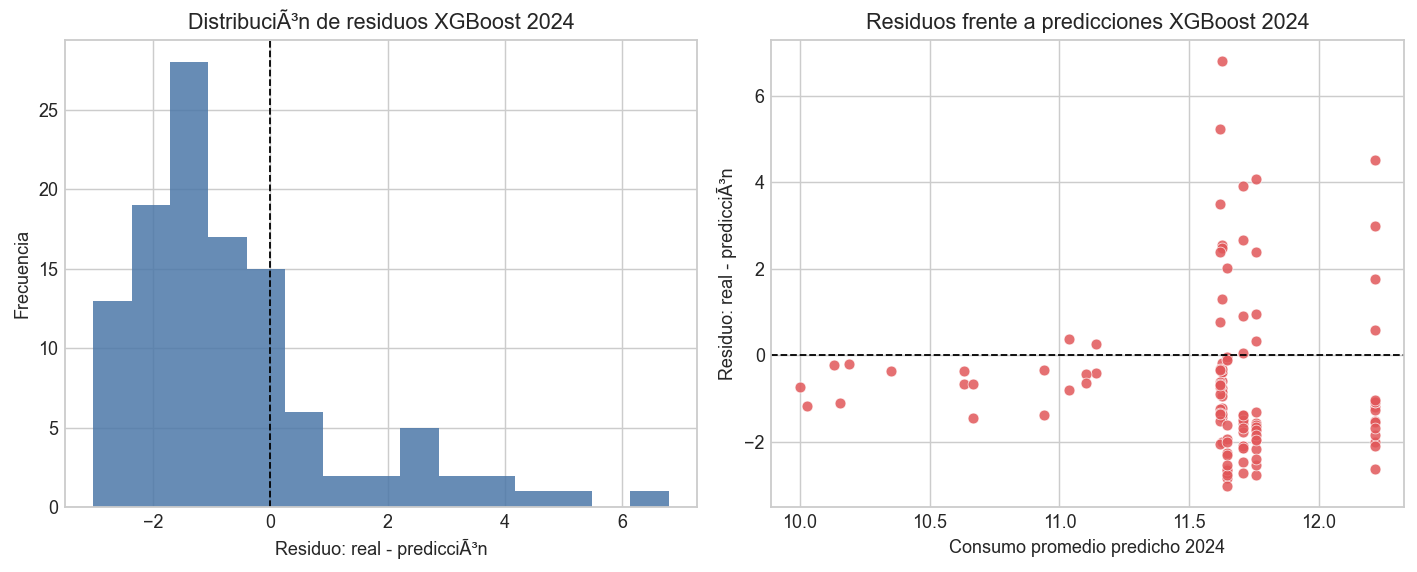

In [9]:
plot_xgb = xgb_local.copy()

plt.figure(figsize=(6.5, 5))
plt.scatter(plot_xgb["valor_real"], plot_xgb["prediccion"], alpha=0.85, edgecolor="white", linewidth=0.4)
min_val = min(plot_xgb["valor_real"].min(), plot_xgb["prediccion"].min())
max_val = max(plot_xgb["valor_real"].max(), plot_xgb["prediccion"].max())
plt.plot([min_val, max_val], [min_val, max_val], color="black", linestyle="--", linewidth=1)
plt.xlabel("Consumo promedio real 2024")
plt.ylabel("Consumo promedio predicho 2024")
plt.title("Valores reales frente a predicciones de XGBoost en 2024")
plt.tight_layout()
plt.show()

metrics_long = comparacion_v11_modelos_2024.melt(
    id_vars=["modelo", "tipo", "ranking"],
    value_vars=["MAE", "RMSE"],
    var_name="mÃ©trica",
    value_name="valor",
)
plt.figure(figsize=(9, 4.8))
metrics_pivot = metrics_long.pivot(index="modelo", columns="mÃ©trica", values="valor").loc[
    comparacion_v11_modelos_2024["modelo"]
]
metrics_pivot.plot(kind="bar", ax=plt.gca(), width=0.75)
plt.xticks(rotation=35, ha="right")
plt.xlabel("Modelo o baseline")
plt.ylabel("Error en escala original de consumo_promedio")
plt.title("ComparaciÃ³n de MAE y RMSE en prueba temporal 2024")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4.8))
locality_error_plot = resultados_v11_por_localidad.sort_values("RMSE_XGBoost", ascending=False)
plt.bar(locality_error_plot[LOCALIDAD_COL], locality_error_plot["RMSE_XGBoost"], color="#4C78A8")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Localidad")
plt.ylabel("RMSE de XGBoost en 2024")
plt.title("Errores de XGBoost por localidad en prueba 2024")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.8))
top_perm = importancia_permutacion_v11.head(10).sort_values("aumento_MAE_promedio")
plt.barh(top_perm["variable"], top_perm["aumento_MAE_promedio"], color="#59A14F")
plt.xlabel("Aumento promedio del MAE al permutar")
plt.ylabel("Variable")
plt.title("Top 10 variables por importancia de permutaciÃ³n")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.8))
top_shap = importancia_shap_v11.head(10).sort_values("media_abs_SHAP_log_target")
plt.barh(top_shap["variable"], top_shap["media_abs_SHAP_log_target"], color="#F28E2B")
plt.xlabel("Media de |SHAP| en escala logarÃ­tmica del target")
plt.ylabel("Variable")
plt.title("Top 10 variables por importancia SHAP")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(plot_xgb["error"], bins=15, color="#4C78A8", alpha=0.85)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("Residuo: real - predicciÃ³n")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("DistribuciÃ³n de residuos XGBoost 2024")

axes[1].scatter(plot_xgb["prediccion"], plot_xgb["error"], color="#E15759", alpha=0.85, edgecolor="white", linewidth=0.4)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Consumo promedio predicho 2024")
axes[1].set_ylabel("Residuo: real - predicciÃ³n")
axes[1].set_title("Residuos frente a predicciones XGBoost 2024")
plt.tight_layout()
plt.show()

## 9. Validaciones finales

In [10]:
required_outputs = [
    "resultados_v11_validacion_temporal_interna.csv",
    "resultados_v11_prueba_2024.csv",
    "resultados_v11_baselines_2024.csv",
    "comparacion_v11_modelos_2024.csv",
    "resultados_v11_por_localidad.csv",
    "importancia_permutacion_v11.csv",
    "importancia_shap_v11.csv",
    "hiperparametros_v11.csv",
    "predicciones_v11_2024.csv",
    "variables_utilizadas_v11.csv",
]

assert not meta_train_final[LOCALIDAD_COL].str.upper().eq("SUMAPAZ").any()
assert not meta_test_2024[LOCALIDAD_COL].str.upper().eq("SUMAPAZ").any()
assert "latitud" not in feature_cols and "longitud" not in feature_cols
assert LOCALIDAD_COL not in feature_cols
assert "_row_id" not in feature_cols and "id_registro_v11" not in feature_cols
assert not set(LEAKAGE_COLUMNS).intersection(feature_cols)
assert set(meta_train_final[YEAR_COL].unique()).issubset({2020, 2021, 2022, 2023})
assert set(meta_test_2024[YEAR_COL].unique()) == {2024}
assert not resultados_validacion_temporal_interna["validation_year"].eq(2024).any()
assert resultados_prueba_2024["metrics_scale"].eq("original_expm1").all()
assert set(xgb_local["id_registro_v11"]) == set(baseline_local["id_registro_v11"])
assert len(resultados_v11_por_localidad) == 19, f"Se esperaban 19 localidades y se encontraron {len(resultados_v11_por_localidad)}."
assert all(Path(path).exists() for path in required_outputs)

current_hashes = assert_historical_notebooks_unchanged()

print("Validaciones completadas correctamente:")
print(" - Sumapaz no estÃ¡ presente en entrenamiento ni prueba.")
print(" - Latitud, longitud y localidad no estÃ¡n entre las variables predictoras de XGBoost.")
print(" - El entrenamiento definitivo usa Ãºnicamente 2020-2023 y la prueba Ãºnicamente 2024.")
print(" - La validaciÃ³n interna de hiperparÃ¡metros no utilizÃ³ 2024.")
print(" - La imputaciÃ³n final se ajustÃ³ con 2020-2023.")
print(" - Las mÃ©tricas se calcularon despuÃ©s de expm1, en escala original.")
print(" - XGBoost y baselines se evaluaron sobre las mismas filas de 2024.")
print(" - No hay variables operativas con fuga de informaciÃ³n en los predictores.")
print(" - Los notebooks v1-v10 conservan los hashes registrados al inicio de v11.")

Validaciones completadas correctamente:
 - Sumapaz no estÃ¡ presente en entrenamiento ni prueba.
 - Latitud, longitud y localidad no estÃ¡n entre las variables predictoras de XGBoost.
 - El entrenamiento definitivo usa Ãºnicamente 2020-2023 y la prueba Ãºnicamente 2024.
 - La validaciÃ³n interna de hiperparÃ¡metros no utilizÃ³ 2024.
 - La imputaciÃ³n final se ajustÃ³ con 2020-2023.
 - Las mÃ©tricas se calcularon despuÃ©s de expm1, en escala original.
 - XGBoost y baselines se evaluaron sobre las mismas filas de 2024.
 - No hay variables operativas con fuga de informaciÃ³n en los predictores.
 - Los notebooks v1-v10 conservan los hashes registrados al inicio de v11.


## 10. Texto propuesto para la tesis y resumen final

In [11]:
xgb_metrics = resultados_prueba_2024.iloc[0]
best_baseline = best_baseline_row
pct_mae, text_mae = describe_comparison(xgb_metrics["MAE"], best_baseline["MAE"], "MAE")
pct_rmse, text_rmse = describe_comparison(xgb_metrics["RMSE"], best_baseline["RMSE"], "RMSE")
xgb_rank = int(comparacion_v11_modelos_2024.loc[comparacion_v11_modelos_2024["modelo"].eq("XGBoost"), "ranking"].iloc[0])
hypothesis_supported = bool(xgb_metrics["RMSE"] < best_baseline["RMSE"])
hypothesis_text = (
    "Los resultados respaldan la hipÃ³tesis operativa de que XGBoost, aun sin coordenadas y sin Sumapaz, supera al mejor baseline histÃ³rico en la prueba temporal 2024."
    if hypothesis_supported
    else "Los resultados no respaldan la hipÃ³tesis operativa de que XGBoost, sin coordenadas y sin Sumapaz, supere al mejor baseline histÃ³rico en la prueba temporal 2024."
)
locality_counts = resultados_v11_por_localidad["modelo_con_mejor_resultado"].value_counts().to_dict()
top_perm_vars = ", ".join(importancia_permutacion_v11.head(5)["variable"].tolist())
top_shap_vars = ", ".join(importancia_shap_v11.head(5)["variable"].tolist())

metodologia = f"""
**MetodologÃ­a propuesta.** En el experimento v11 se evaluÃ³ un modelo XGBRegressor para estimar el consumo promedio de agua en 2024 bajo una particiÃ³n temporal estricta. Se excluyÃ³ completamente la localidad de Sumapaz, con lo cual el conjunto depurado quedÃ³ conformado por {len(df)} registros. La localidad se conservÃ³ Ãºnicamente como metadato para los anÃ¡lisis territoriales y la construcciÃ³n de baselines histÃ³ricos, pero no se incorporÃ³ como predictor del modelo. TambiÃ©n se excluyeron latitud, longitud, las variables operativas con fuga de informaciÃ³n y las variables redundantes utilizadas en los experimentos previos. El entrenamiento final utilizÃ³ {int(train_final_mask.sum())} registros de 2020 a 2023 y la prueba final se realizÃ³ una sola vez sobre {int(test_2024_mask.sum())} registros de 2024. La variable objetivo se transformÃ³ mediante log1p durante el entrenamiento y todas las mÃ©tricas se calcularon en la escala original despuÃ©s de aplicar expm1.
"""

resultados = f"""
**Resultados propuestos.** En la prueba temporal 2024, XGBoost obtuvo MAE={xgb_metrics['MAE']:.4f}, RMSE={xgb_metrics['RMSE']:.4f} y RÂ²={xgb_metrics['R2']:.4f}. El mejor baseline fue {best_baseline['modelo_o_baseline']}, con MAE={best_baseline['MAE']:.4f}, RMSE={best_baseline['RMSE']:.4f} y RÂ²={best_baseline['R2']:.4f}. {text_mae} {text_rmse} En el ranking global por RMSE, XGBoost ocupÃ³ la posiciÃ³n {xgb_rank} entre los modelos y baselines evaluados.
"""

comparacion = f"""
**ComparaciÃ³n con baselines propuesta.** La comparaciÃ³n se realizÃ³ sobre exactamente las mismas observaciones de 2024 para todos los mÃ©todos. Los baselines se construyeron Ãºnicamente con informaciÃ³n histÃ³rica de 2020 a 2023. La diferencia porcentual de XGBoost frente al mejor baseline fue de {pct_mae:.2f} % en MAE y {pct_rmse:.2f} % en RMSE. En el anÃ¡lisis por localidad, la distribuciÃ³n observada fue: {locality_counts}. Esta evidencia permite evaluar si el modelo no lineal aporta valor adicional frente a reglas histÃ³ricas simples cuando se eliminan las coordenadas y la localidad como predictores.
"""

interpretacion = f"""
**InterpretaciÃ³n de variables propuesta.** La importancia por permutaciÃ³n identificÃ³ como variables principales: {top_perm_vars}. Por su parte, SHAP identificÃ³ como variables principales: {top_shap_vars}. Estos resultados deben interpretarse como contribuciones predictivas dentro del modelo entrenado y no como relaciones causales. La ausencia de latitud, longitud y localidad en los predictores permite analizar el aporte de las variables climÃ¡ticas, temporales y operativas no filtradas sin depender de identificadores territoriales directos.
"""

discusion = f"""
**DiscusiÃ³n propuesta.** El experimento v11 introduce una prueba metodolÃ³gica mÃ¡s restrictiva que los experimentos con variables espaciales, porque elimina coordenadas, excluye Sumapaz y evalÃºa el desempeÃ±o exclusivamente en 2024. Bajo estas condiciones, el desempeÃ±o del modelo debe interpretarse como una estimaciÃ³n de su capacidad temporal sin apoyo de identificadores geogrÃ¡ficos directos. La comparaciÃ³n con baselines histÃ³ricos resulta central porque estos mÃ©todos simples capturan patrones persistentes por localidad y bimestre utilizando solamente informaciÃ³n previa a 2024.
"""

hipotesis = f"""
**EvaluaciÃ³n de la hipÃ³tesis propuesta.** {hypothesis_text} Esta conclusiÃ³n se basa en la comparaciÃ³n directa del RMSE y el MAE sobre los registros de 2024, manteniendo aislado el conjunto de prueba durante la selecciÃ³n de hiperparÃ¡metros y el ajuste del preprocesamiento.
"""

conclusion = f"""
**ConclusiÃ³n propuesta.** El experimento confirma la utilidad de evaluar los modelos predictivos bajo esquemas temporales estrictos y frente a baselines histÃ³ricos. La exclusiÃ³n de Sumapaz y de las coordenadas permite estimar el desempeÃ±o de XGBoost sin identificadores espaciales directos, lo cual fortalece la interpretaciÃ³n metodolÃ³gica de los resultados y delimita el alcance real del modelo para apoyar la predicciÃ³n del consumo hÃ­drico en BogotÃ¡.
"""

for section in [metodologia, resultados, comparacion, interpretacion, discusion, hipotesis, conclusion]:
    display(Markdown(section))

resumen_final = {
    "registros_originales": int(n_original),
    "registros_sumapaz_excluidos": int(n_sumapaz),
    "registros_despues_de_excluir_sumapaz": int(len(df)),
    "registros_entrenamiento_2020_2023": int(train_final_mask.sum()),
    "registros_prueba_2024": int(test_2024_mask.sum()),
    "n_variables_utilizadas": int(len(feature_cols)),
    "variables_utilizadas": feature_cols,
    "mejor_configuracion_xgboost": {k: v for k, v in best_params.items() if k not in {"n_jobs", "tree_method"}},
    "resultados_xgboost_2024": xgb_metrics.to_dict(),
    "mejor_baseline": best_baseline.to_dict(),
    "diferencia_pct_mae_vs_mejor_baseline": float(pct_mae),
    "diferencia_pct_rmse_vs_mejor_baseline": float(pct_rmse),
    "evaluacion_hipotesis": hypothesis_text,
}
print(json.dumps(resumen_final, indent=2, ensure_ascii=False))


**MetodologÃ­a propuesta.** En el experimento v11 se evaluÃ³ un modelo XGBRegressor para estimar el consumo promedio de agua en 2024 bajo una particiÃ³n temporal estricta. Se excluyÃ³ completamente la localidad de Sumapaz, con lo cual el conjunto depurado quedÃ³ conformado por 570 registros. La localidad se conservÃ³ Ãºnicamente como metadato para los anÃ¡lisis territoriales y la construcciÃ³n de baselines histÃ³ricos, pero no se incorporÃ³ como predictor del modelo. TambiÃ©n se excluyeron latitud, longitud, las variables operativas con fuga de informaciÃ³n y las variables redundantes utilizadas en los experimentos previos. El entrenamiento final utilizÃ³ 456 registros de 2020 a 2023 y la prueba final se realizÃ³ una sola vez sobre 114 registros de 2024. La variable objetivo se transformÃ³ mediante log1p durante el entrenamiento y todas las mÃ©tricas se calcularon en la escala original despuÃ©s de aplicar expm1.



**Resultados propuestos.** En la prueba temporal 2024, XGBoost obtuvo MAE=1.5829, RMSE=1.9325 y RÂ²=-0.0648. El mejor baseline fue Baseline - media histÃ³rica localidad-bimestre, con MAE=0.6877, RMSE=0.9618 y RÂ²=0.7362. XGBoost presentÃ³ un MAE 130.19 % mayor que el mejor baseline. XGBoost presentÃ³ un RMSE 100.92 % mayor que el mejor baseline. En el ranking global por RMSE, XGBoost ocupÃ³ la posiciÃ³n 4 entre los modelos y baselines evaluados.



**ComparaciÃ³n con baselines propuesta.** La comparaciÃ³n se realizÃ³ sobre exactamente las mismas observaciones de 2024 para todos los mÃ©todos. Los baselines se construyeron Ãºnicamente con informaciÃ³n histÃ³rica de 2020 a 2023. La diferencia porcentual de XGBoost frente al mejor baseline fue de 130.19 % en MAE y 100.92 % en RMSE. En el anÃ¡lisis por localidad, la distribuciÃ³n observada fue: {'El baseline supera a XGBoost': 17, 'Resultados similares': 2}. Esta evidencia permite evaluar si el modelo no lineal aporta valor adicional frente a reglas histÃ³ricas simples cuando se eliminan las coordenadas y la localidad como predictores.



**InterpretaciÃ³n de variables propuesta.** La importancia por permutaciÃ³n identificÃ³ como variables principales: PS, QV2M, T2M, ALLSKY_SRF_ALB, BIMESTRE_sin. Por su parte, SHAP identificÃ³ como variables principales: PS, T2M, PRECTOTCORR, ALLSKY_SRF_ALB, CLOUD_AMT. Estos resultados deben interpretarse como contribuciones predictivas dentro del modelo entrenado y no como relaciones causales. La ausencia de latitud, longitud y localidad en los predictores permite analizar el aporte de las variables climÃ¡ticas, temporales y operativas no filtradas sin depender de identificadores territoriales directos.



**DiscusiÃ³n propuesta.** El experimento v11 introduce una prueba metodolÃ³gica mÃ¡s restrictiva que los experimentos con variables espaciales, porque elimina coordenadas, excluye Sumapaz y evalÃºa el desempeÃ±o exclusivamente en 2024. Bajo estas condiciones, el desempeÃ±o del modelo debe interpretarse como una estimaciÃ³n de su capacidad temporal sin apoyo de identificadores geogrÃ¡ficos directos. La comparaciÃ³n con baselines histÃ³ricos resulta central porque estos mÃ©todos simples capturan patrones persistentes por localidad y bimestre utilizando solamente informaciÃ³n previa a 2024.



**EvaluaciÃ³n de la hipÃ³tesis propuesta.** Los resultados no respaldan la hipÃ³tesis operativa de que XGBoost, sin coordenadas y sin Sumapaz, supere al mejor baseline histÃ³rico en la prueba temporal 2024. Esta conclusiÃ³n se basa en la comparaciÃ³n directa del RMSE y el MAE sobre los registros de 2024, manteniendo aislado el conjunto de prueba durante la selecciÃ³n de hiperparÃ¡metros y el ajuste del preprocesamiento.



**ConclusiÃ³n propuesta.** El experimento confirma la utilidad de evaluar los modelos predictivos bajo esquemas temporales estrictos y frente a baselines histÃ³ricos. La exclusiÃ³n de Sumapaz y de las coordenadas permite estimar el desempeÃ±o de XGBoost sin identificadores espaciales directos, lo cual fortalece la interpretaciÃ³n metodolÃ³gica de los resultados y delimita el alcance real del modelo para apoyar la predicciÃ³n del consumo hÃ­drico en BogotÃ¡.


{
  "registros_originales": 596,
  "registros_sumapaz_excluidos": 26,
  "registros_despues_de_excluir_sumapaz": 570,
  "registros_entrenamiento_2020_2023": 456,
  "registros_prueba_2024": 114,
  "n_variables_utilizadas": 22,
  "variables_utilizadas": [
    "año",
    "ALLSKY_SFC_LW_DWN",
    "ALLSKY_SFC_SW_DWN",
    "ALLSKY_SRF_ALB",
    "CLOUD_AMT",
    "GWETPROF",
    "GWETROOT",
    "GWETTOP",
    "ONI",
    "PRECTOTCORR",
    "PRECTOTCORR_SUM",
    "PS",
    "QV2M",
    "RH2M",
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "TS",
    "WS10M",
    "WS2M",
    "BIMESTRE_sin",
    "BIMESTRE_cos"
  ],
  "mejor_configuracion_xgboost": {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "random_state": 42,
    "n_estimators": 100,
    "learning_rate": 0.05,
    "max_depth": 4,
    "min_child_weight": 1,
    "subsample": 1.0,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 5.0
  },
  "resultados_xgboost_2024": {
    "modelo": "XGBoost",
    "descripcio